# 03 · Correlations and Key Influencing Factors

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')
df = pd.read_csv('../data/processed/titanic_clean.csv')
df['SexCode'] = (df['Sex']=='female').astype(int)   # 1 = female

## 1. Correlation matrix

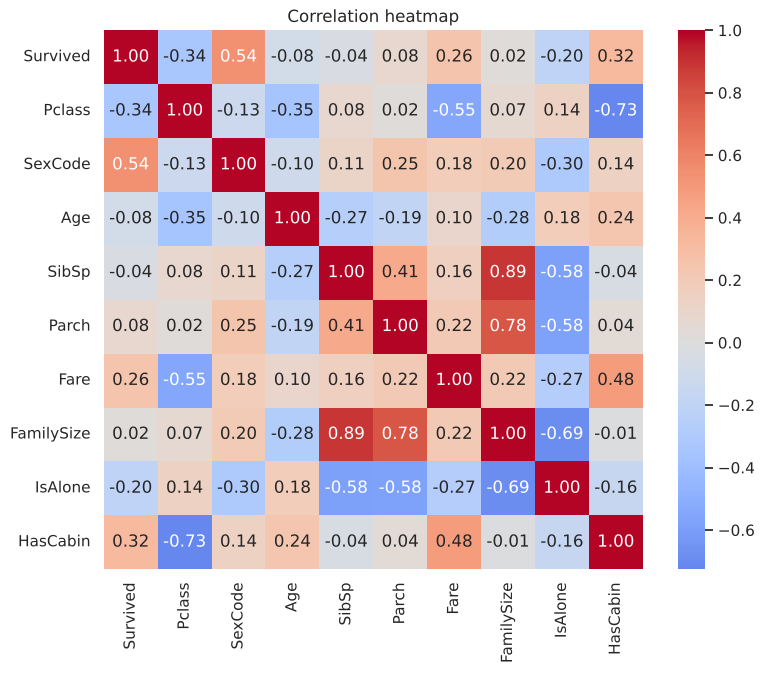

In [2]:
cols = ['Survived','Pclass','SexCode','Age','SibSp','Parch','Fare','FamilySize','IsAlone','HasCabin']
corr = df[cols].corr()
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation heatmap')
plt.savefig('../images/07_correlation_heatmap.png', bbox_inches='tight'); plt.show()

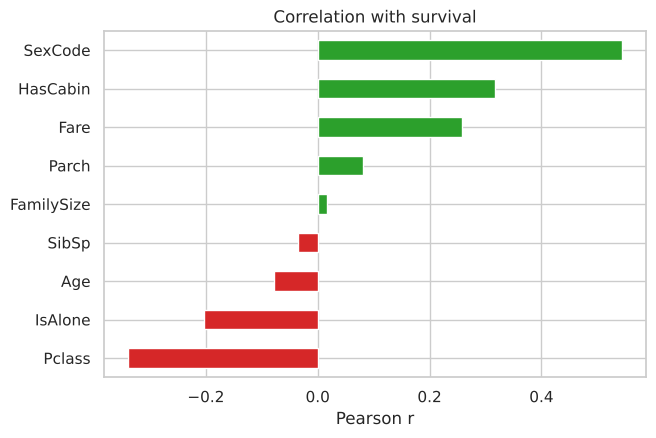

SexCode       0.543
Pclass       -0.338
HasCabin      0.317
Fare          0.257
IsAlone      -0.203
Parch         0.082
Age          -0.079
SibSp        -0.035
FamilySize    0.017
Name: Survived, dtype: float64

In [3]:
target = corr['Survived'].drop('Survived').sort_values(key=abs, ascending=False)
plt.figure(figsize=(7,4.5))
colors = ['#d62728' if v<0 else '#2ca02c' for v in target]
target.sort_values().plot(kind='barh', color=[('#d62728' if v<0 else '#2ca02c') for v in target.sort_values()])
plt.title('Correlation with survival'); plt.xlabel('Pearson r')
plt.savefig('../images/08_survival_correlations.png', bbox_inches='tight'); plt.show()
target.round(3)

## 2. Statistical significance tests

In [4]:
# Chi-square: categorical factors vs survival
for col in ['Sex','Pclass','Embarked','IsAlone']:
    chi2, p, dof, _ = stats.chi2_contingency(pd.crosstab(df[col], df['Survived']))
    print(f'{col:9s} chi2 = {chi2:7.2f}   p = {p:.2e}   ->', 'significant' if p<0.05 else 'not significant')

Sex       chi2 =  260.72   p = 1.20e-58   -> significant
Pclass    chi2 =  102.89   p = 4.55e-23   -> significant
Embarked  chi2 =   25.96   p = 2.30e-06   -> significant
IsAlone   chi2 =   36.00   p = 1.97e-09   -> significant


In [5]:
# t-tests: do survivors differ in Age / Fare?
for col in ['Age','Fare']:
    a = df.loc[df.Survived==1, col]; b = df.loc[df.Survived==0, col]
    t, p = stats.ttest_ind(a, b, equal_var=False)
    print(f'{col:5s} survivors mean = {a.mean():6.2f}, non-survivors mean = {b.mean():6.2f}, t = {t:5.2f}, p = {p:.2e}')

Age   survivors mean =  28.07, non-survivors mean =  30.21, t = -2.30, p = 2.20e-02
Fare  survivors mean =  48.40, non-survivors mean =  22.12, t =  6.84, p = 2.70e-11


## 3. Ranking influencing factors

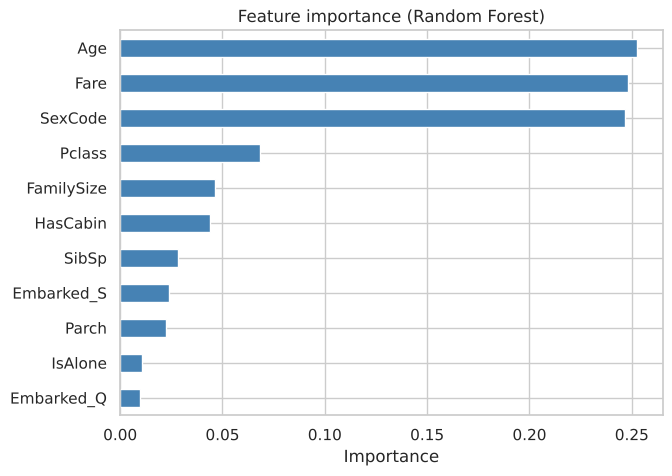

Age           0.252
Fare          0.248
SexCode       0.247
Pclass        0.069
FamilySize    0.046
HasCabin      0.044
SibSp         0.028
Embarked_S    0.024
Parch         0.022
IsAlone       0.011
Embarked_Q    0.009
dtype: float64

In [6]:
from sklearn.ensemble import RandomForestClassifier
X = pd.get_dummies(df[['Pclass','SexCode','Age','SibSp','Parch','Fare','FamilySize','IsAlone','HasCabin','Embarked']], drop_first=True)
rf = RandomForestClassifier(n_estimators=300, random_state=42).fit(X, df['Survived'])
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(7,5)); imp.plot(kind='barh', color='steelblue')
plt.title('Feature importance (Random Forest)'); plt.xlabel('Importance')
plt.savefig('../images/09_feature_importance.png', bbox_inches='tight'); plt.show()
imp.sort_values(ascending=False).round(3)

> Feature importance here is used only to **rank** factors for exploration, not to claim causation.